# Rigshospitalet High-Impact Non-Eye Operations Notebook

This notebook isolates **non-eye procedures** and identifies operational patterns that affect large numbers of operations.

Focus areas:
- Weekend effect across all non-eye operations
- Procedure-level delay burden (volume x delay)
- Action list prioritized by impact

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

RH_BLUE = '#0077B6'
ACCENT_RED = '#E63946'
ACCENT_GREEN = '#2A9D8F'

DATA_PATH = 'completed_operations.csv'
df = pd.read_csv(DATA_PATH, sep=';', encoding='utf-8', low_memory=False)
print(f'Loaded {len(df):,} rows')

Loaded 133,158 rows


In [2]:
# Prepare core columns
df['Forsinkelse (minutter)'] = pd.to_numeric(df['Forsinkelse (minutter)'], errors='coerce')
df['Dato'] = pd.to_datetime(df['Dato'], errors='coerce', format='mixed')

df['Procedure_Name'] = (
    df['Procedure - Tekst & ID']
    .astype(str)
    .str.replace(r'\s*\[.*\]', '', regex=True)
    .str.strip()
)

# Broad exclusion of eye-related procedures
eye_pattern = (
    r'KATARAKT|FAKO|\u00d8JE|OJE|OFTAL|RETINA|GLAUKOM|VITREK|VITREKTOMI|'
    r'PHTH|LASIK|CORNEA|HORNHI|LINSE|IOL|TRABEK|IRIS|SILIKONEOLIE|AMOTIO|'
    r'PARS PLANA|PHAKO|YAG|CHALAZ|DACRYO|LACRIM|PTOSIS'
)

non_eye = df[~df['Procedure_Name'].str.contains(eye_pattern, case=False, na=False)].copy()
non_eye['Day_of_Week'] = non_eye['Dato'].dt.day_name()

print(f'Non-eye rows: {len(non_eye):,}')
print(f'Non-eye unique cases: {non_eye["Case-ID Anonymous"].nunique():,}')

/var/folders/_3/spv5x2714tbb6xsc2xwzh3hr0000gn/T/ipykernel_97605/2212574654.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Procedure_Name'] = (


Non-eye rows: 95,348
Non-eye unique cases: 86,381


## Finding 1: Weekend Effect Across All Non-Eye Operations

If weekends are systematically more delayed than weekdays, this points to staffing/staging constraints with broad operational impact.

             mean_delay  median_delay      n
Day_of_Week                                 
Monday             10.6           8.0  18542
Tuesday            10.2           8.0  18540
Wednesday          11.0           9.0  19233
Thursday           10.5           8.0  16368
Friday             11.3           8.0  16682
Saturday           35.7          21.0   2898
Sunday             32.3          20.0   2457


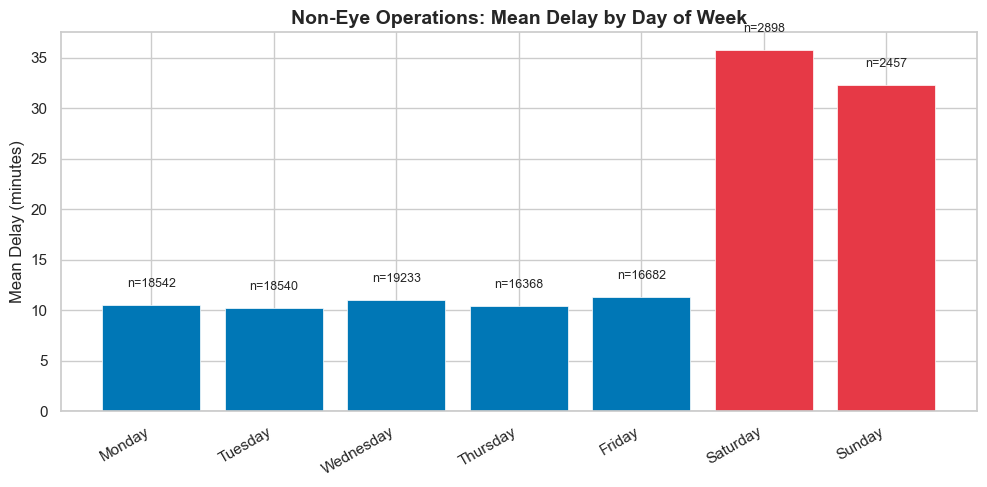

In [3]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = (
    non_eye.groupby('Day_of_Week')['Forsinkelse (minutter)']
    .agg(mean_delay='mean', median_delay='median', n='count')
    .reindex(day_order)
    .dropna(subset=['n'])
)

print(dow.round(1))

fig, ax = plt.subplots(figsize=(10, 5))
colors = [ACCENT_RED if d in ['Saturday', 'Sunday'] else RH_BLUE for d in dow.index]
bars = ax.bar(dow.index, dow['mean_delay'], color=colors, edgecolor='white', linewidth=0.5)

for bar, n in zip(bars, dow['n']):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'n={int(n)}', ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Mean Delay (minutes)')
ax.set_title('Non-Eye Operations: Mean Delay by Day of Week', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Finding 2: Delay Burden by Procedure (Volume x Mean Delay)

A procedure with moderate delay but very high volume can create a larger total burden than a rare severe outlier.

                                       n  mean_delay  median_delay  \
Procedure_Name                                                       
EKSPLORATIV LAPAROTOMI               560        35.5          21.0   
JJ-KATETER ANLÆGGELSE                510        38.8          19.0   
TONSILLEKTOMI                       1182        14.9          10.0   
GASTROSKOPI                          562        30.8          19.0   
KRONISK SUBDURALT HÆMATOM - BORHUL   559        30.2          25.0   
EVACUATIO UTERI OG ABORT             545        23.3           4.0   
LUMBAL PROLAPS - MIKROSKOP           851        12.8           7.0   
TUR-B                                786        13.6           8.0   
PTA UE ANGIO                        1012        10.5           9.0   
SEPTUMPLASTIK                       1089         9.6           8.0   

                                    total_delay_min  
Procedure_Name                                       
EKSPLORATIV LAPAROTOMI                      19853.0

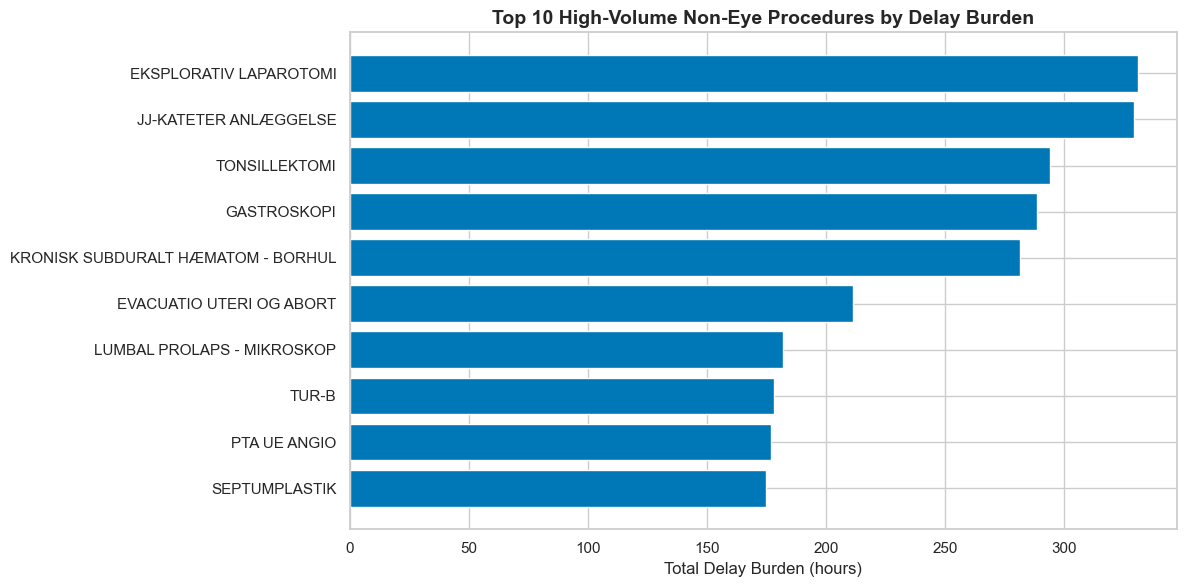

In [4]:
proc = (
    non_eye.groupby('Procedure_Name')['Forsinkelse (minutter)']
    .agg(n='count', mean_delay='mean', median_delay='median')
    .dropna(subset=['mean_delay'])
)

proc['total_delay_min'] = proc['n'] * proc['mean_delay']
high_volume = proc[proc['n'] >= 500].sort_values('total_delay_min', ascending=False)
top10 = high_volume.head(10).copy()

print(top10[['n', 'mean_delay', 'median_delay', 'total_delay_min']].round(1))

fig, ax = plt.subplots(figsize=(12, 6))
plot_data = top10.sort_values('total_delay_min', ascending=True)
ax.barh(plot_data.index, plot_data['total_delay_min'] / 60, color=RH_BLUE, edgecolor='white')
ax.set_xlabel('Total Delay Burden (hours)')
ax.set_title('Top 10 High-Volume Non-Eye Procedures by Delay Burden', fontweight='bold')
plt.tight_layout()
plt.show()

## Finding 3: Prioritized Action List

Build a practical action queue: prioritize procedures with high total burden and meaningful case volume.

In [5]:
actions = high_volume.reset_index().copy()
actions['total_delay_hours'] = actions['total_delay_min'] / 60
actions = actions[['Procedure_Name', 'n', 'mean_delay', 'median_delay', 'total_delay_hours']]
actions = actions.sort_values('total_delay_hours', ascending=False)

print('Recommended priority list (first 15):')
print(actions.head(15).round(1).to_string(index=False))

Recommended priority list (first 15):
                          Procedure_Name    n  mean_delay  median_delay  total_delay_hours
                  EKSPLORATIV LAPAROTOMI  560        35.5          21.0              330.9
                   JJ-KATETER ANLÆGGELSE  510        38.8          19.0              329.4
                           TONSILLEKTOMI 1182        14.9          10.0              294.1
                             GASTROSKOPI  562        30.8          19.0              288.6
      KRONISK SUBDURALT HÆMATOM - BORHUL  559        30.2          25.0              281.6
                EVACUATIO UTERI OG ABORT  545        23.3           4.0              211.5
              LUMBAL PROLAPS - MIKROSKOP  851        12.8           7.0              182.1
                                   TUR-B  786        13.6           8.0              178.3
                            PTA UE ANGIO 1012        10.5           9.0              176.8
                           SEPTUMPLASTIK 1089       

## Finding 4: Deep Dive on 3 Priority Procedures

This deep dive focuses on:
- EKSPLORATIV LAPAROTOMI
- JJ-KATETER ANLÆGGELSE
- GASTROSKOPI

For each procedure, we compare expected vs actual timing at each step and identify where the delay accumulates the most.

Outputs:
- Procedure-level delay profile (mean, median, p90)
- Step duration gap by procedure (actual duration minus planned duration)
- Primary bottleneck step and recoverable hours if the bottleneck is reduced by 25%

Step-level expected vs actual summary (positive = slower than planned):
                    Procedure_Name                                Metric                               Step    n  mean_min  median_min
            EKSPLORATIV LAPAROTOMI Milestone slippage (actual - planned)                    Room prep start  516       7.5         1.5
            EKSPLORATIV LAPAROTOMI Milestone slippage (actual - planned)                  Patient leaves OR  560      34.9        29.0
            EKSPLORATIV LAPAROTOMI Milestone slippage (actual - planned)                      Patient in OR  560      35.5        21.0
            EKSPLORATIV LAPAROTOMI  Step duration gap (actual - planned) Patient in OR -> Patient leaves OR  560      -0.6        -7.0
            EKSPLORATIV LAPAROTOMI  Step duration gap (actual - planned)        Prep start -> Patient in OR  516      29.0        19.0
          EVACUATIO UTERI OG ABORT Milestone slippage (actual - planned)                      Patient in OR  545      

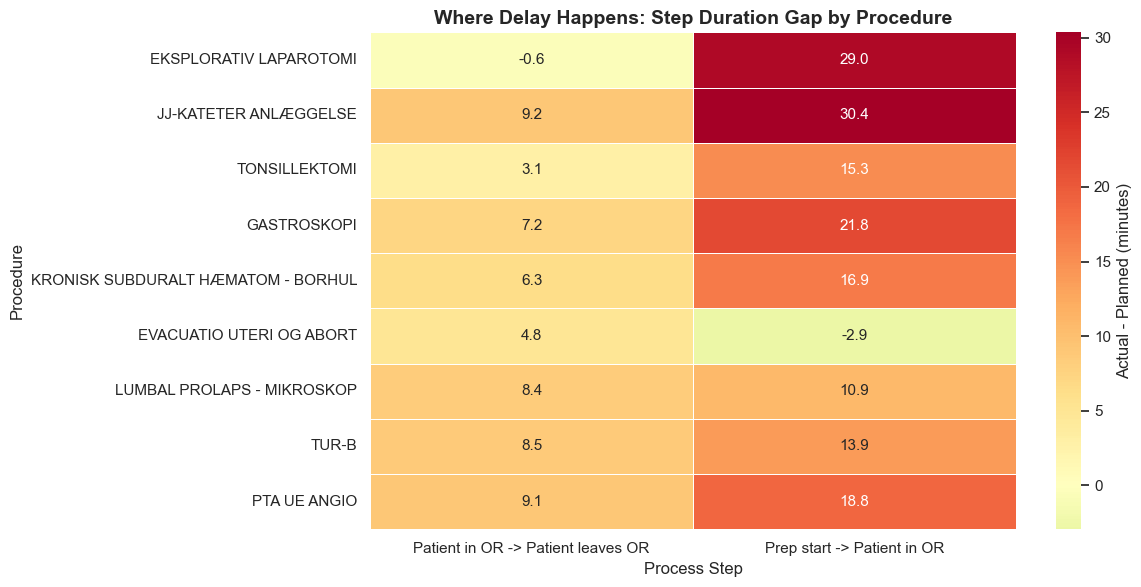


Actionable insights (largest bottleneck per procedure):
                    Procedure_Name               Main_bottleneck_step  Mean_extra_min                                                                         Action_hint
             JJ-KATETER ANLÆGGELSE        Prep start -> Patient in OR            30.4 Strengthen pre-op readiness, room setup checklist, and first-case setup discipline.
            EKSPLORATIV LAPAROTOMI        Prep start -> Patient in OR            29.0 Strengthen pre-op readiness, room setup checklist, and first-case setup discipline.
                       GASTROSKOPI        Prep start -> Patient in OR            21.8 Strengthen pre-op readiness, room setup checklist, and first-case setup discipline.
                      PTA UE ANGIO        Prep start -> Patient in OR            18.8 Strengthen pre-op readiness, room setup checklist, and first-case setup discipline.
KRONISK SUBDURALT HÆMATOM - BORHUL        Prep start -> Patient in OR            16.9 Strengt

In [ ]:
deep_dive_procedures = [
    'EKSPLORATIV LAPAROTOMI',
    'JJ-KATETER ANLÆGGELSE',
    'GASTROSKOPI',
]

step_pairs = [
    (
        'Prep start -> Patient in OR',
        'Planlagt stue klargøring start',
        'Patient på stuen (Planlagt)',
        'Stue klargøring start',
        'Patient på stuen',
    ),
    (
        'Patient in OR -> Patient leaves OR',
        'Patient på stuen (Planlagt)',
        'Patient forlader stuen (Planlagt)',
        'Patient på stuen',
        'Patient forlader stuen',
    ),
    (
        'Total: Prep start -> Patient leaves OR',
        'Planlagt stue klargøring start',
        'Patient forlader stuen (Planlagt)',
        'Stue klargøring start',
        'Patient forlader stuen',
    ),
]

needed = sorted({col for _, ps, pe, acs, ace in step_pairs for col in [ps, pe, acs, ace]})
for col in needed:
    if col in non_eye.columns:
        non_eye[col] = pd.to_datetime(non_eye[col], errors='coerce', format='mixed')

# 1) Procedure-level delay profile
profile = (
    non_eye[non_eye['Procedure_Name'].isin(deep_dive_procedures)]
    .groupby('Procedure_Name')['Forsinkelse (minutter)']
    .agg(
        n='count',
        mean_delay='mean',
        median_delay='median',
        p90=lambda s: s.quantile(0.90),
    )
    .reindex(deep_dive_procedures)
)
print('Procedure-level delay profile:')
print(profile.round(1).to_string())

# 2) Step gap analysis (actual duration - planned duration)
step_records = []
for proc_name in deep_dive_procedures:
    sub = non_eye[non_eye['Procedure_Name'] == proc_name].copy()

    for step_name, p_start, p_end, a_start, a_end in step_pairs:
        cols_ok = all(c in sub.columns for c in [p_start, p_end, a_start, a_end])
        if not cols_ok:
            continue

        planned_dur = (sub[p_end] - sub[p_start]).dt.total_seconds() / 60
        actual_dur = (sub[a_end] - sub[a_start]).dt.total_seconds() / 60
        gap = (actual_dur - planned_dur).dropna()

        if gap.empty:
            continue

        step_records.append({
            'Procedure_Name': proc_name,
            'Step': step_name,
            'n': int(gap.shape[0]),
            'mean_gap_min': gap.mean(),
            'median_gap_min': gap.median(),
            'p90_gap_min': gap.quantile(0.90),
        })

step_gap = pd.DataFrame(step_records)
print('\nStep duration gap summary (actual - planned):')
print(step_gap.round(1).to_string(index=False))

# Compact matrix for heatmap
compact = (
    step_gap.pivot(index='Procedure_Name', columns='Step', values='mean_gap_min')
    .reindex(deep_dive_procedures)
)

fig, ax = plt.subplots(figsize=(11, 4.8))
sns.heatmap(
    compact,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.4,
    cbar_kws={'label': 'Actual - Planned (minutes)'},
    ax=ax,
)
ax.set_title('Deep Dive: Mean Step Duration Gap by Procedure', fontweight='bold')
ax.set_xlabel('Process step')
ax.set_ylabel('Procedure')
plt.tight_layout()
plt.show()

# 3) Actionable bottleneck ranking with recoverable-hours estimate
actions = []
for proc_name in deep_dive_procedures:
    sub = step_gap[(step_gap['Procedure_Name'] == proc_name) & (step_gap['Step'] != 'Total: Prep start -> Patient leaves OR')].copy()
    if sub.empty:
        continue

    top = sub.sort_values('mean_gap_min', ascending=False).iloc[0]
    bottleneck_step = top['Step']
    mean_extra = float(top['mean_gap_min'])
    n_cases = int(profile.loc[proc_name, 'n']) if proc_name in profile.index else 0

    # Conservative pilot estimate: reduce bottleneck by 25%
    recoverable_hours_25pct = max(mean_extra, 0) * n_cases * 0.25 / 60

    if bottleneck_step == 'Prep start -> Patient in OR':
        action_hint = 'Pre-op readiness huddle, transport trigger at T-20, and room setup checklist at T-30.'
    else:
        action_hint = 'In-room flow standard: closure prep before end, discharge handoff trigger, and exit-ready checklist.'

    actions.append({
        'Procedure_Name': proc_name,
        'Main_bottleneck_step': bottleneck_step,
        'Mean_extra_min': mean_extra,
        'Recoverable_hours_if_25pct_cut': recoverable_hours_25pct,
        'Action_hint': action_hint,
    })

actionable = pd.DataFrame(actions).sort_values('Recoverable_hours_if_25pct_cut', ascending=False)
print('\nAction plan for deep-dive procedures:')
print(actionable.round(1).to_string(index=False))

# 4) Distribution check for operational risk (tail behavior)
fig, ax = plt.subplots(figsize=(11, 4.8))
sns.boxplot(
    data=non_eye[non_eye['Procedure_Name'].isin(deep_dive_procedures)],
    y='Procedure_Name',
    x='Forsinkelse (minutter)',
    order=deep_dive_procedures,
    palette='coolwarm',
    flierprops=dict(marker='o', markersize=3, alpha=0.35),
    ax=ax,
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Deep Dive: Delay Distribution by Procedure', fontweight='bold')
ax.set_xlabel('Delay (minutes)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Next Steps

1. Validate coding of eye-procedure exclusions with a clinician or coding specialist.
2. For top 5 procedures, compare delay by room, weekday/weekend, and acute/planned split.
3. Convert one high-impact finding into a pilot intervention with before/after measurement.